In [1]:
# qiskit==1.4.3
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp
from qiskit.synthesis import LieTrotter
from scipy.linalg import expm
from scipy.linalg import norm
import numpy as np
# customize quantum circuit for quantum simulation 
from qiskit import QuantumRegister
from qiskit.circuit.library import RZZGate, RXGate
from qiskit import transpile
from qiskit import qasm2, qasm3

# 参数
n = 5       # 自旋数
J = 0.5     # 相互作用强度
h = 1.0     # 横场强度
t = 1     # 演化时间

# 定义 Pauli 矩阵
X = np.array([[0, 1], [1, 0]])  # Pauli-X 矩阵
Y = np.array([[0, -1j], [1j, 0]])  # Pauli-Y 矩阵
Z = np.array([[1, 0], [0, -1]])  # Pauli-Z 矩阵
I = np.eye(2)  # 单位矩阵


# 生成五比特的 Ising 模型哈密顿量
def ising_hamiltonian(num_bits, J=0.5, h=1):
    H1 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H2 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    H3 = np.zeros((2**num_bits, 2**num_bits), dtype=complex)
    
    # 添加最近邻自旋的交互作用 (σz σz)
    for i in range(0, num_bits - 1, 2):  # 只考虑相邻自旋，不包含周期性边界
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        # Heisenberg 模型的交互作用项可以是 σx σx, σy σy 或 σz σz
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H3 += -J * interaction_term
    
    for i in range(1, num_bits - 1, 2):
        # 生成针对 (i, i+1) 对的 σz σz 交互项
        interaction_term = np.kron(np.eye(2**i), np.kron(np.kron(Z, Z), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(X, X), np.eye(2**(num_bits-i-2))))
        # interaction_term += np.kron(np.eye(2**i), np.kron(np.kron(Y, Y), np.eye(2**(num_bits-i-2))))
        H2 += -J * interaction_term
        
    # 添加外部磁场项 (σx)s
    for i in range(num_bits):
        field_term = np.kron(np.eye(2**i), np.kron(X, np.eye(2**(num_bits-i-1))))
        H1 += -h * field_term
        
    return H1, H2, H3, H1 + H2 + H3

H1, H2, H3, H = ising_hamiltonian(n, J, h)
np.save('Ising_Hamiltonian.npy', H)
U = expm(-1j * H * t)

# spectral norm of U
norm(U, ord=2)

1.0000000000000004

In [8]:
# 创建一个初始态，这里以 |0...1⟩ 初始态为例
initial_state = Statevector.from_label('0' * (n - 1) + '1') 
psi0 = initial_state.data
initial_state

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2))


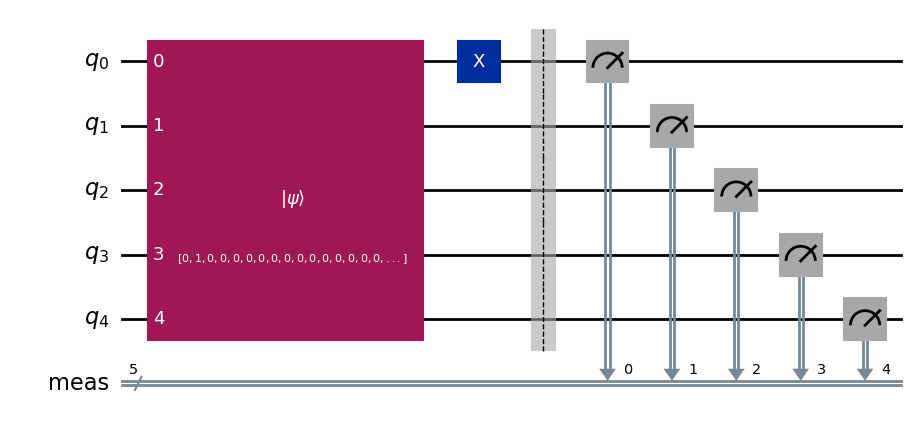

In [37]:
qreg = QuantumRegister(5, 'q')
qc = QuantumCircuit(qreg)
qc.initialize(initial_state, qreg)
qc.x(0)
final_state = initial_state.evolve(qc)
qc.measure_all()

qc.draw('mpl')

In [38]:
from qiskit_aer import AerSimulator

# 创建一个模拟器
simulator = AerSimulator()

# 在模拟器上运行电路，shots=1000 表示重复测量 1000 次
result = simulator.run(qc, shots=1000).result()

# 获取测量统计结果
counts = result.get_counts()

print(counts)

{'00000': 1000}


In [5]:
import tensorcircuit as tc
import numpy as np

# 设置后端
tc.set_backend("numpy")

# 创建一个 3 量子比特的简单电路
c = tc.Circuit(3, inputs = np.array([0, 0, 0, 0, 0, 0, 0, 1]))

# 应用基本量子门
c.h(0)          # Hadamard 门在第 0 个量子比特
c.x(1)          # Pauli-X 门在第 1 个量子比特  
c.y(2)          # Pauli-Y 门在第 2 个量子比特

# 应用旋转门
c.rx(0, theta=np.pi/4)  # X 旋转
c.ry(1, theta=np.pi/3)  # Y 旋转
c.rz(2, theta=np.pi/6)  # Z 旋转

# 应用控制门
c.cnot(0, 1)    # CNOT 门，控制比特 0，目标比特 1
c.cz(1, 2)      # Controlled-Z 门

# 获取最终量子态
final_state = c.state()
print("最终量子态:")
print(final_state)

# 计算各个量子比特的期望值
print("\n各量子比特的 Z 期望值:")
for i in range(3):
    exp_z = c.expectation_ps(z=[i])
    print(f"量子比特 {i}: {exp_z:.4f}")

# 计算态概率分布
probabilities = np.abs(final_state)**2
print(f"\n态概率分布:")
for i, prob in enumerate(probabilities):
    if prob > 0.001:  # 只显示概率大于 0.1% 的态
        print(f"|{format(i, '03b')}⟩: {prob:.4f}")

最终量子态:
[ 0.07993064-0.6071335j  0.        +0.j         0.04614799-0.3505287j
  0.        +0.j        -0.04614799+0.3505287j  0.        +0.j
 -0.07993064+0.6071335j  0.        +0.j       ]

各量子比特的 Z 期望值:
量子比特 0: 0.0000-0.0000j
量子比特 1: 0.0000-0.0000j
量子比特 2: 1.0000-0.0000j

态概率分布:
|000⟩: 0.3750
|010⟩: 0.1250
|100⟩: 0.1250
|110⟩: 0.3750


In [10]:
circuit = tc.Circuit(3, inputs = np.array([0, 1, 0, 0, 0, 0, 0, 0]))

circuit.x(0)

print(circuit.state())

# 计算态概率分布
probabilities = np.abs(circuit.state())**2
print(f"\n态概率分布:")
for i, prob in enumerate(probabilities):
    if prob > 0.001:  # 只显示概率大于 0.1% 的态
        print(f"|{format(i, '03b')}⟩: {prob:.4f}")
        
circuit.draw()

[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]

态概率分布:
|101⟩: 1.0000


┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
          
q_2: ─────